In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report,accuracy_score
from sklearn.tree import plot_tree as plt_tree
from sklearn.preprocessing import StandardScaler



In [ ]:
df= pd.read_csv('geopolitical_dataset.csv')
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df.drop('target', axis=1))
y= df['target']
print(y)
print(df_scaled)
df.head()

0      1
1      1
2      1
3      1
4      1
      ..
995    1
996    2
997    1
998    2
999    1
Name: target, Length: 1000, dtype: int64
[[-0.39630103 -0.10852903 -1.05978406 ... -1.26686003 -1.51863941
  -0.75350062]
 [ 1.57695733 -1.31059103 -1.05978406 ... -0.13018884  0.57695516
  -0.75876128]
 [ 0.82789256  0.4066404  -1.05978406 ...  0.05633947  0.5719879
  -0.65885031]
 ...
 [-1.21044009  0.64705281 -1.05978406 ...  0.34030978 -1.7260013
  -0.61852242]
 [ 1.57532388  0.92180984 -1.05978406 ...  0.03692896 -0.49163347
   0.21538933]
 [-0.15154831  1.4713239  -1.05978406 ...  1.34176138  1.3284375
   0.12203737]]


,military_power_ratio,troop_movement,nuclear_capability,nuclear_warheads,gdp_ratio,sanctions_intensity,trade_dependency,ideology_distance,political_stability,historical_conflict,border_distance,news_sentiment,nationalism_index,leader_aggression,target
0,1.061810,46,0,20,1.514162,7,0.949273,0.844864,0.934033,5,793.537402,-0.740587,0.084002,0.274637,1
1,1.926071,11,0,157,1.915973,7,0.879601,0.359676,0.766351,6,85.599553,-0.092492,0.681526,0.273081,1
2,1.597991,61,0,268,0.903452,9,0.907042,0.687234,0.657950,0,183.457885,0.013860,0.680110,0.302622,1
3,1.397988,79,0,161,1.213110,6,0.991533,0.312834,0.823896,0,758.403673,0.374780,0.669080,0.612313,1
4,0.734028,87,1,259,1.451510,4,0.208315,0.060906,0.647520,4,21.986522,0.266567,0.942334,0.438333,1


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(df_scaled, y, test_size=0.2, random_state=42)

In [ ]:
model=DecisionTreeClassifier(
    criterion = "entropy",
    max_depth=8,
    # min_samples_leaf=30,
    class_weight="balanced",
    random_state=42)
model.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [ ]:
y_pred=model.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
# print(classification_report(y_test, y_pred))


[[ 5  1  0  0]
 [ 8 80 11  1]
 [ 0 13 51  5]
 [ 0  1 10 14]]
Accuracy: 0.75


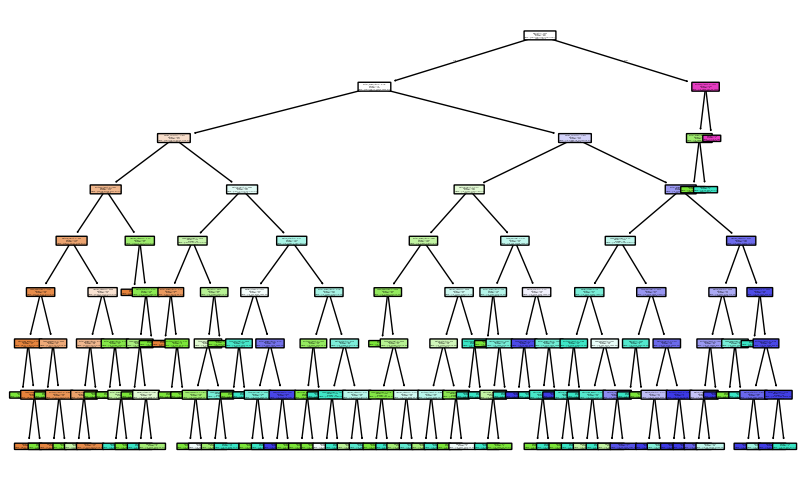

In [ ]:

plt.figure(figsize=(10,6))
plt_tree(model, filled=True, rounded=True, feature_names=list(df.drop('target', axis=1).columns), class_names=['Class 0', 'Class 1', 'Class 2', 'Class 3', 'Class 4'])
plt.show()
